# Evaluate — UCF v3 Baseline (Intra-FF++ C23)

## 📋 Hướng dẫn Input Kaggle

| Dataset | Nội dung | Biến đường dẫn |
| :--- | :--- | :--- |
| `thinhphan272/ffpp-c23-face-cache` | Ảnh frame đã crop + manifest | `CACHE_DIR` |
| Dataset chứa `ucf_best.pth` | Checkpoint + `train_history.csv` | `BEST_PATH`, `TRAIN_HISTORY_CSV` |

> **Notebook evaluate-only** — UCF dùng đầy đủ nhánh disentanglement khi inference (`forward_inference`).


## 1. Cấu hình

In [1]:
import os, glob, time, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA CÁC ĐƯỜNG DẪN NÀY ====================
CACHE_DIR         = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
MANIFEST_CSV      = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX        = "/kaggle/working/ffpp_c23_cache"

BEST_PATH         = "/kaggle/input/datasets/thinhphan272/ucf-train-pth/ucf_v3/ucf_best.pth"
TRAIN_HISTORY_CSV = os.path.join(os.path.dirname(BEST_PATH), "train_history.csv")
OUT_DIR           = "/kaggle/working/eval_ucf"
# ================================================================

DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE          = 256
ENCODER_FEAT_DIM  = 512
HALF_FP_DIM       = ENCODER_FEAT_DIM // 2  # 256
METHOD_MAP        = {"original": 0, "Deepfakes": 1, "Face2Face": 2, "FaceSwap": 3, "NeuralTextures": 4}
N_METHODS         = len(METHOD_MAP)
MODEL_NAME        = "UCF v3 Baseline"

os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(CACHE_DIR), f"Không tìm thấy CACHE_DIR: {CACHE_DIR}"
assert os.path.exists(BEST_PATH), f"Không tìm thấy checkpoint: {BEST_PATH}"
print(f"Device: {DEVICE}")
print(f"Checkpoint: {BEST_PATH} ({round(os.path.getsize(BEST_PATH)/1e6, 1)} MB)")
print(f"train_history.csv: {'tồn tại ✓' if os.path.exists(TRAIN_HISTORY_CSV) else 'không tìm thấy ⚠'}")


Device: cuda
Checkpoint: /kaggle/input/datasets/thinhphan272/ucf-train-pth/ucf_v3/ucf_best.pth (204.4 MB)
train_history.csv: tồn tại ✓


## 2. Đọc manifest, lấy tập test

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)
manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists"]) & (manifest["n_frames"] >= 8)
].reset_index(drop=True)
test_df = manifest_ok[manifest_ok["split"] == "test"].reset_index(drop=True)
print(f"Test videos: {len(test_df)}")
print(test_df.groupby(["label", "method"])["video_id"].count())


Test videos: 700
label  method        
0      original          140
1      Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
Name: video_id, dtype: int64


## 3. Dataset (video-level eval)

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_frame(path):
    img = cv2.imread(path)
    if img is None:
        return torch.zeros(3, IMG_SIZE, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_f = img.astype(np.float32) / 255.0
    inp = (img_f - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(inp.transpose(2, 0, 1)).float()

class VideoEvalDataset(Dataset):
    def __init__(self, df):
        self.rows = []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if files:
                self.rows.append((row.video_id, files, row.label, row.method))
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        vid_id, files, label, method = self.rows[idx]
        imgs = torch.stack([load_frame(f) for f in files])
        return imgs, label, method, vid_id

test_ds  = VideoEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test DataLoader: {len(test_ds)} videos sẵn sàng đánh giá.")


Test DataLoader: 700 videos sẵn sàng đánh giá.


## 4. Kiến trúc UCFModel (copy từ training notebook — PHẢI khớp 100%)

In [4]:
!pip install -q timm
import timm

def make_xception(pretrained=False, max_retries=3):
    for attempt in range(max_retries):
        try:
            # timm legacy_xception: forward_features() → (B, 2048, 8, 8) cho 256x256 input
            return timm.create_model("legacy_xception", pretrained=pretrained, features_only=False)
        except Exception as e:
            print(f"  Retry {attempt+1}: {e}")
            time.sleep(5)
            if attempt == max_retries - 1: raise


# ─── Các module phụ trợ (COPY từ DeepfakeBench ucf_detector.py) ───

class AdaIN(nn.Module):
    """Adaptive Instance Normalization — official code."""
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps

    def c_norm(self, x, bs, ch, eps=1e-7):
        x_var = x.var(dim=-1) + eps
        x_std = x_var.sqrt().view(bs, ch, 1, 1)
        x_mean = x.mean(dim=-1).view(bs, ch, 1, 1)
        return x_std, x_mean

    def forward(self, x, y):
        assert x.size(0) == y.size(0)
        size = x.size()
        bs, ch = size[:2]
        x_ = x.view(bs, ch, -1)
        y_ = y.reshape(bs, ch, -1)
        x_std, x_mean = self.c_norm(x_, bs, ch, eps=self.eps)
        y_std, y_mean = self.c_norm(y_, bs, ch, eps=self.eps)
        out = ((x - x_mean.expand(size)) / x_std.expand(size)) \
              * y_std.expand(size) + y_mean.expand(size)
        return out


def r_double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True))


class Conditional_UNet(nn.Module):
    """Official Conditional_UNet decoder — 3×AdaIN + Upsample + Tanh."""
    def __init__(self):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dropout = nn.Dropout(p=0.3)

        self.adain3 = AdaIN()
        self.adain2 = AdaIN()
        self.adain1 = AdaIN()

        self.dconv_up3 = r_double_conv(ENCODER_FEAT_DIM, ENCODER_FEAT_DIM // 2)  # 512→256
        self.dconv_up2 = r_double_conv(ENCODER_FEAT_DIM // 2, ENCODER_FEAT_DIM // 4)  # 256→128
        self.dconv_up1 = r_double_conv(ENCODER_FEAT_DIM // 4, ENCODER_FEAT_DIM // 8)  # 128→64

        self.conv_last = nn.Conv2d(ENCODER_FEAT_DIM // 8, 3, 1)
        self.up_last = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.activation = nn.Tanh()

    def forward(self, c, x):
        # c = fingerprint (style), x = content (base)
        x = self.adain3(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up3(x)
        c = self.upsample(c); c = self.dropout(c); c = self.dconv_up3(c)

        x = self.adain2(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up2(x)
        c = self.upsample(c); c = self.dropout(c); c = self.dconv_up2(c)

        x = self.adain1(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up1(x)

        x = self.conv_last(x)
        out = self.up_last(x)
        return self.activation(out)


class Conv2d1x1(nn.Module):
    """Official Conv2d1x1 projection block — keeps spatial dims."""
    def __init__(self, in_f, hidden_dim, out_f):
        super().__init__()
        self.conv2d = nn.Sequential(
            nn.Conv2d(in_f, hidden_dim, 1, 1),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 1, 1),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(hidden_dim, out_f, 1, 1))

    def forward(self, x):
        return self.conv2d(x)


class Head(nn.Module):
    """Official Head — returns (logits, pooled_features)."""
    def __init__(self, in_f, hidden_dim, out_f):
        super().__init__()
        self.do = nn.Dropout(0.2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.LeakyReLU(inplace=True),
            nn.Linear(hidden_dim, out_f))

    def forward(self, x):
        bs = x.size(0)
        x_feat = self.pool(x).view(bs, -1)
        x = self.mlp(x_feat)
        x = self.do(x)
        return x, x_feat


class UCFModel(nn.Module):
    """UCF model — official architecture from DeepfakeBench."""
    def __init__(self, pretrained=True):
        super().__init__()
        # Encoders: fingerprint + content
        self.encoder_f = make_xception(pretrained)
        self.encoder_c = make_xception(pretrained)

        # Adapt 2048 → encoder_feat_dim (512) vì timm output 2048
        self.adapt_f = nn.Sequential(nn.Conv2d(2048, ENCODER_FEAT_DIM, 1), nn.LeakyReLU(True))
        self.adapt_c = nn.Sequential(nn.Conv2d(2048, ENCODER_FEAT_DIM, 1), nn.LeakyReLU(True))

        # Projection blocks: split fingerprint → specific + shared (common)
        self.block_spe = Conv2d1x1(ENCODER_FEAT_DIM, HALF_FP_DIM, HALF_FP_DIM)
        self.block_sha = Conv2d1x1(ENCODER_FEAT_DIM, HALF_FP_DIM, HALF_FP_DIM)

        # Classification heads
        self.head_spe = Head(HALF_FP_DIM, ENCODER_FEAT_DIM, N_METHODS)
        self.head_sha = Head(HALF_FP_DIM, ENCODER_FEAT_DIM, 2)

        # Conditional UNet decoder
        self.con_gan = Conditional_UNet()

    def get_features(self, x):
        """Extract spatial feature maps (B, 512, H, W)."""
        f_raw = self.encoder_f.forward_features(x)  # (B, 2048, 8, 8)
        c_raw = self.encoder_c.forward_features(x)  # (B, 2048, 8, 8)
        f_all = self.adapt_f(f_raw)  # (B, 512, 8, 8)
        c_all = self.adapt_c(c_raw)  # (B, 512, 8, 8)
        return f_all, c_all

    def forward_train(self, images):
        """Training: images = cat([real, fake], dim=0), bs = total."""
        f_all, c_all = self.get_features(images)

        # Split fingerprint → specific + shared (common)
        f_spe = self.block_spe(f_all)   # (B, 256, H, W)
        f_share = self.block_sha(f_all) # (B, 256, H, W)

        bs = f_share.size(0)

        # ★ Feature shuffle augmentation (official code line 267-277)
        aug_idx = random.random()
        if aug_idx < 0.7:
            # Shuffle within real group
            idx_real = list(range(0, bs // 2))
            random.shuffle(idx_real)
            f_share[0: bs // 2] = f_share[idx_real]
            # Shuffle within fake group
            idx_fake = list(range(bs // 2, bs))
            random.shuffle(idx_fake)
            f_share[bs // 2: bs] = f_share[idx_fake]

        # Concat spe + share for reconstruction
        f_combined = torch.cat((f_spe, f_share), dim=1)  # (B, 512, H, W)

        # Split by real/fake halves
        f2, f1 = f_combined.chunk(2, dim=0)  # f1=real_fingerprint, f2=fake_fingerprint
        c2, c1 = c_all.chunk(2, dim=0)

        # Self-reconstruction
        self_rec_1 = self.con_gan(f1, c1)
        self_rec_2 = self.con_gan(f2, c2)
        # Cross-reconstruction
        cross_rec_1 = self.con_gan(f1, c2)
        cross_rec_2 = self.con_gan(f2, c1)

        # Classification heads
        out_spe, spe_feat = self.head_spe(f_spe)
        out_sha, sha_feat = self.head_sha(f_share)

        return {
            "cls": out_sha,          # (B, 2) common classification
            "cls_spe": out_spe,      # (B, 5) specific classification
            "feat": sha_feat,        # (B, 256) pooled common features
            "feat_spe": spe_feat,    # (B, 256) pooled specific features
            "rec_imgs": (cross_rec_1, cross_rec_2, self_rec_1, self_rec_2),
        }

    def forward_inference(self, x):
        """Inference: chỉ dùng fingerprint encoder + common head."""
        f_raw = self.encoder_f.forward_features(x)
        f_all = self.adapt_f(f_raw)
        f_share = self.block_sha(f_all)
        out_sha, sha_feat = self.head_sha(f_share)
        return out_sha


model = UCFModel(pretrained=False).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"UCF Model: {n_params/1e6:.1f}M params")

# Quick check output shapes
with torch.no_grad():
    dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
    f, c = model.get_features(dummy)
    print(f"Feature maps: f={f.shape}, c={c.shape}")
    out = model.forward_inference(dummy)
    print(f"Inference output: {out.shape}")


UCF Model: 50.9M params
Feature maps: f=torch.Size([4, 512, 8, 8]), c=torch.Size([4, 512, 8, 8])
Inference output: torch.Size([4, 2])


## 5. Hàm tính metric chuẩn hóa

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import numpy as np

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fp / max(fp + tn, 1)
    frr = fn / max(fn + tp, 1)
    return far, frr

def calc_far_frr_curve(y_true, y_score, n_points=200):
    thresholds = np.linspace(0, 1, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr = calc_far_frr(y_true, y_score, t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_score)
    acc = accuracy_score(y_true, y_pred)
    eer = calc_eer(y_true, y_score)
    eer_thr = find_eer_threshold(y_true, y_score)
    far05, frr05 = calc_far_frr(y_true, y_score, 0.5)
    far_eer, frr_eer = calc_far_frr(y_true, y_score, eer_thr)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return {
        "auc": auc, "acc": acc, "eer": eer, "eer_threshold": eer_thr,
        "far_at_0.5": far05, "frr_at_0.5": frr05,
        "far_at_eer": far_eer, "frr_at_eer": frr_eer,
        "cm_at_0.5": cm, "roc_fpr": fpr, "roc_tpr": tpr
    }


## 6. Hàm vẽ biểu đồ chuẩn hóa

In [6]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Confusion Matrix CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_confusion_matrix_standard(cm, model_name, out_path=None, threshold=0.5):
    fig, ax = plt.subplots(figsize=(6.0, 5.2), dpi=150)
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    classes = ["Real (0)", "Fake (1)"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(classes, fontsize=12, fontweight="bold")
    ax.set_yticks([0, 1]); ax.set_yticklabels(classes, fontsize=12, fontweight="bold")
    total = np.sum(cm); thresh = cm.max() / 2.0
    labels_tag = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = count / total * 100 if total > 0 else 0
            tag = labels_tag[i][j]
            color = "white" if count > thresh else "#08306b"
            ax.text(j, i, f"{tag}\n{count:,}\n({pct:.1f}%)",
                    ha="center", va="center", color=color,
                    fontsize=13, fontweight="bold", linespacing=1.3)
    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_title(f"Confusion Matrix @ threshold={threshold}\n{model_name}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Training Curves CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_training_curves_standard(hist_df, model_name, out_path=None):
    epochs = hist_df["epoch"].values
    train_loss = hist_df["train_loss"].values if "train_loss" in hist_df.columns else None
    val_loss, vl_label = None, "Val Loss"
    for col in ["val_loss", "val_loss_ema", "val_loss_raw"]:
        if col in hist_df.columns:
            val_loss = hist_df[col].values
            if "ema" in col: vl_label = "Val Loss (EMA)"
            elif "raw" in col: vl_label = "Val Loss (Raw)"
            break
    val_auc = next((hist_df[c].values for c in ["val_auc","val_auc_ema","val_auc_raw"] if c in hist_df.columns), None)
    val_eer = next((hist_df[c].values for c in ["val_eer","val_eer_ema","val_eer_raw"] if c in hist_df.columns), None)
    val_acc = next((hist_df[c].values for c in ["val_acc","val_acc_ema","val_acc_raw"] if c in hist_df.columns), None)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=120)
    # Panel 1: Loss
    ax = axes[0]
    if train_loss is not None:
        ax.plot(epochs, train_loss, "o-", color="#1f77b4", lw=2, ms=4, label="Train Loss")
    if val_loss is not None:
        ax.plot(epochs, val_loss, "s--", color="#d62728", lw=2, ms=4, label=vl_label)
        bi = int(np.argmin(val_loss))
        ax.scatter([epochs[bi]], [val_loss[bi]], color="#d62728", s=100, zorder=5,
                   edgecolors="black", marker="*", label=f"Min Val Loss ({val_loss[bi]:.4f})")
    ax.set_title("Loss (Train vs Val)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 2: AUC
    ax = axes[1]
    if val_auc is not None:
        ax.plot(epochs, val_auc, "^-", color="#2ca02c", lw=2, ms=4, label="Val AUC")
        bi = int(np.argmax(val_auc))
        ax.scatter([epochs[bi]], [val_auc[bi]], color="#2ca02c", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best AUC ({val_auc[bi]*100:.2f}%)")
    ax.set_title("Val AUC", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")
    # Panel 3: EER
    ax = axes[2]
    if val_eer is not None:
        ax.plot(epochs, val_eer * 100, "v-", color="#9467bd", lw=2, ms=4, label="Val EER (%)")
        bi = int(np.argmin(val_eer))
        ax.scatter([epochs[bi]], [val_eer[bi]*100], color="#9467bd", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Min EER ({val_eer[bi]*100:.2f}%)")
    ax.set_title("Val EER (lower is better)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("EER (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 4: Accuracy
    ax = axes[3]
    if val_acc is not None:
        ax.plot(epochs, val_acc * 100, "d-", color="#17becf", lw=2, ms=4, label="Val Acc (%)")
        bi = int(np.argmax(val_acc))
        ax.scatter([epochs[bi]], [val_acc[bi]*100], color="#17becf", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best Acc ({val_acc[bi]*100:.2f}%)")
    ax.set_title("Val Accuracy", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")

    plt.suptitle(f"Training Progress — {model_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


## 7. Load checkpoint + Đánh giá test (TTA lật ngang)

Nạp checkpoint tốt nhất: epoch=8 (val_auc=0.9917602040816327)


Evaluating test set: 100%|██████████| 700/700 [04:44<00:00,  2.46it/s]



=== KẾT QUẢ TEST (FF++ C23) — UCF v3 Baseline + TTA ===
Loss (CE)           : 0.1023
Accuracy            : 97.00%
AUC                 : 99.16%
EER                 : 3.57%
FAR @ threshold=0.5 : 7.14%
FRR @ threshold=0.5 : 1.96%
FAR @ EER           : 3.57%  |  FRR @ EER: 3.57%

Confusion Matrix @ 0.5:  TN=130  FP=10  FN=11  TP=549


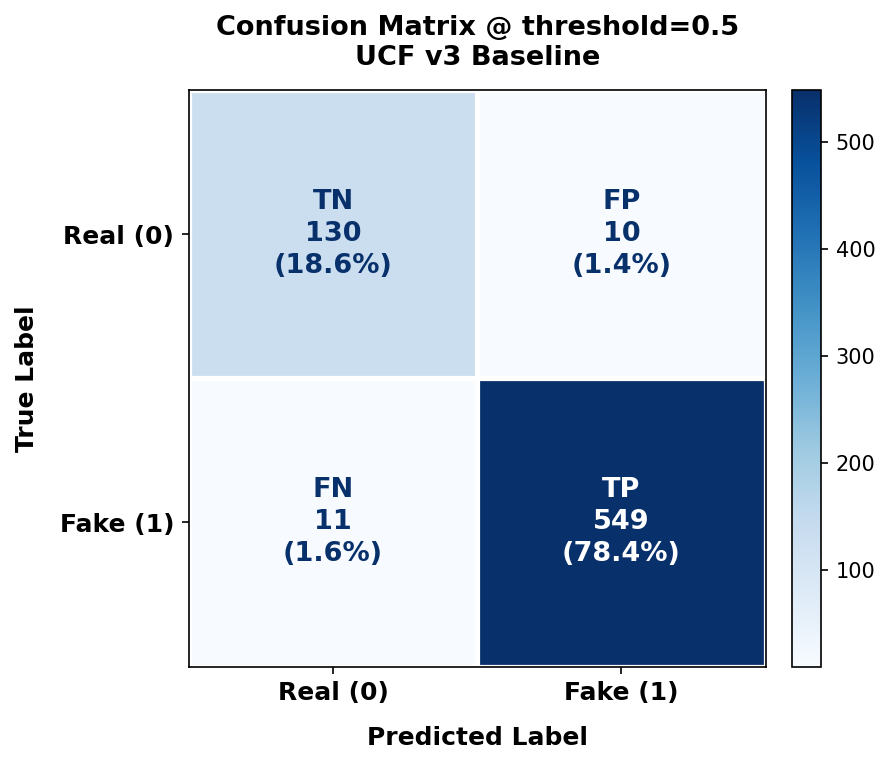

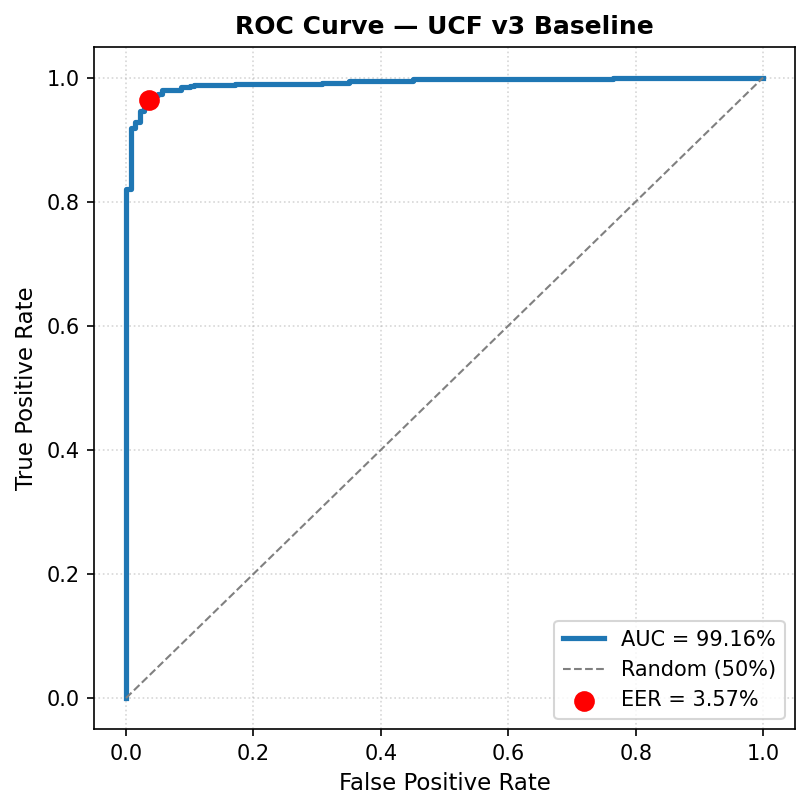

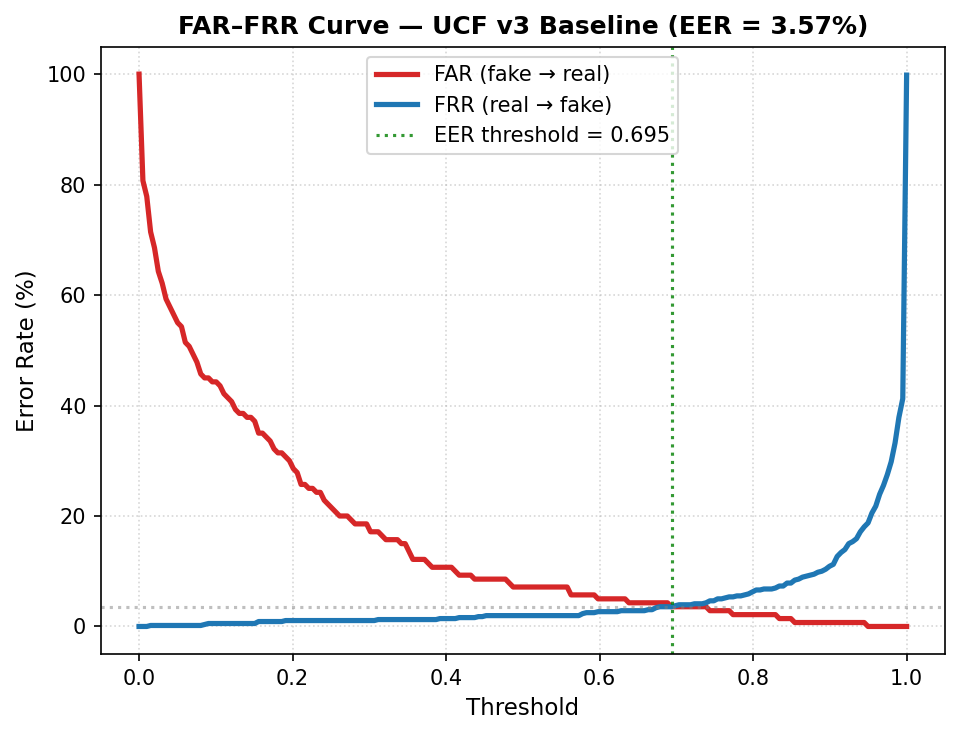


=== Breakdown theo phương pháp (real + từng loại fake) ===
        method      auc      eer   n
     Deepfakes 0.997449 0.028571 280
     Face2Face 0.995459 0.035714 280
      FaceSwap 0.997296 0.028571 280
NeuralTextures 0.976276 0.057143 280

✓ Đã lưu toàn bộ kết quả vào /kaggle/working/eval_ucf/


In [7]:
MODEL_NAME = "UCF v3 Baseline"
criterion_cls = nn.CrossEntropyLoss()

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
val_auc_log = ckpt.get('val_metrics', {}).get('auc', 'N/A')
print(f"Nạp checkpoint tốt nhất: epoch={ckpt.get('epoch', '?')} (val_auc={val_auc_log})")

@torch.no_grad()
def evaluate_test_tta(eval_model, loader):
    eval_model.eval()
    y_true, y_score, methods, losses = [], [], [], []
    for frames, label, method, _vid in tqdm(loader, desc="Evaluating test set"):
        frames = frames.squeeze(0).to(DEVICE)
        frames_flip = torch.flip(frames, dims=[3])

        logits_orig = eval_model.forward_inference(frames)
        logits_flip = eval_model.forward_inference(frames_flip)

        prob_orig = F.softmax(logits_orig, dim=1)[:, 1].mean()
        prob_flip = F.softmax(logits_flip, dim=1)[:, 1].mean()
        prob = ((prob_orig + prob_flip) / 2).item()

        label_dev = torch.tensor([label.item() if hasattr(label, 'item') else label], dtype=torch.long, device=DEVICE)
        mean_logits = (logits_orig.mean(0, keepdim=True) + logits_flip.mean(0, keepdim=True)) / 2
        losses.append(criterion_cls(mean_logits, label_dev).item())

        y_score.append(prob)
        y_true.append(label.item() if hasattr(label, 'item') else label)
        methods.append(method[0] if isinstance(method, (tuple, list)) else method)
    return np.asarray(y_true), np.asarray(y_score), np.asarray(methods), float(np.mean(losses))

y_true, y_score, methods, test_loss = evaluate_test_tta(model, test_loader)
test_metrics = calc_metrics(y_true, y_score)
test_metrics["loss"] = test_loss

print(f"\n=== KẾT QUẢ TEST (FF++ C23) — {MODEL_NAME} + TTA ===")
print(f"Loss (CE)           : {test_metrics['loss']:.4f}")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"FAR @ EER           : {test_metrics['far_at_eer']*100:.2f}%  |  FRR @ EER: {test_metrics['frr_at_eer']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix @ 0.5:  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

# ── 1. Confusion Matrix CHUẨN HÓA ──
plot_confusion_matrix_standard(cm, MODEL_NAME,
                                out_path=os.path.join(OUT_DIR, "confusion_matrix.png"))

# ── 2. ROC Curve ──
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=150)
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2.5, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]],
           color="red", zorder=5, s=80, label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate", fontsize=11); ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"ROC Curve — {MODEL_NAME}", fontsize=12, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 3. FAR–FRR Curve ──
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
ax.plot(thr, fars * 100, lw=2.5, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2.5, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.8,
           label=f"EER threshold = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Threshold", fontsize=11); ax.set_ylabel("Error Rate (%)", fontsize=11)
ax.set_title(f"FAR–FRR Curve — {MODEL_NAME} (EER = {test_metrics['eer']*100:.2f}%)",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 4. Breakdown theo phương pháp fake ──
test_ordered = test_df.reset_index(drop=True)
real_mask = (methods == "original")
rows = []
for m_name in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    sel = real_mask | (methods == m_name)
    yt, ys = y_true[sel], y_score[sel]
    if len(np.unique(yt)) < 2:
        rows.append({"method": m_name, "auc": float("nan"), "eer": float("nan"), "n": int(sel.sum())})
        continue
    m_calc = calc_metrics(yt, ys)
    rows.append({"method": m_name, "auc": m_calc["auc"], "eer": m_calc["eer"], "n": int(sel.sum())})
bd = pd.DataFrame(rows)
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== Breakdown theo phương pháp (real + từng loại fake) ===")
print(bd.to_string(index=False))

# ── 5. Lưu test_results_intra.csv ──
n_params = sum(p.numel() for p in model.parameters())
result_row = {
    "model": "UCF", "input_modality": "spatial_rgb",
    "params_M": round(n_params / 1e6, 2),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "loss_intra": test_metrics["loss"], "acc_intra": test_metrics["acc"],
    "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
for _, r in bd.iterrows():
    result_row[f"auc_{r['method']}"] = r["auc"]
    result_row[f"eer_{r['method']}"] = r["eer"]
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\n✓ Đã lưu toàn bộ kết quả vào {OUT_DIR}/")


## 8. Training Curves (đọc từ train_history.csv)

Đã tải 18 epochs từ /kaggle/input/datasets/thinhphan272/ucf-train-pth/ucf_v3/train_history.csv


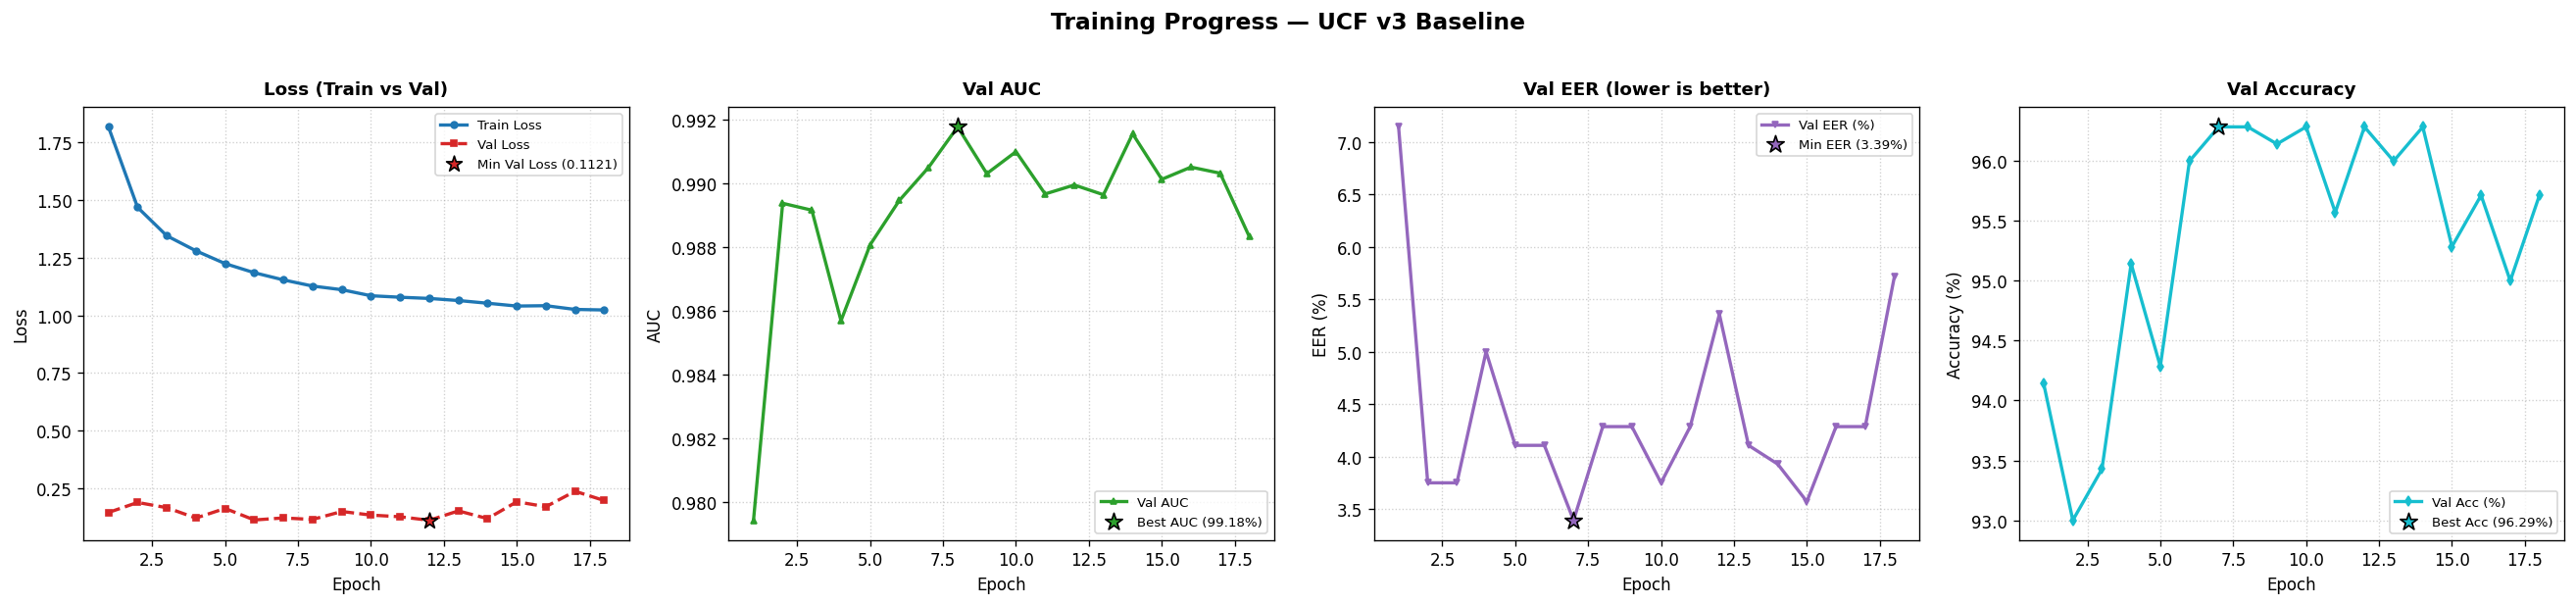

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Vẽ Training Curves CHUẨN HÓA (đọc từ train_history.csv kèm checkpoint)
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(TRAIN_HISTORY_CSV):
    hist_df = pd.read_csv(TRAIN_HISTORY_CSV)
    print(f"Đã tải {len(hist_df)} epochs từ {TRAIN_HISTORY_CSV}")
    plot_training_curves_standard(hist_df, MODEL_NAME,
                                   out_path=os.path.join(OUT_DIR, "training_curves.png"))
else:
    print(f"⚠️ Không tìm thấy {TRAIN_HISTORY_CSV} — bỏ qua Training Curves.")
    print("   Thêm train_history.csv vào Kaggle Input cùng thư mục với checkpoint để hiển thị.")


## 9. ⚠️ Lưu kết quả

**Save Version → Save & Run All (Commit)** → **Output** → **New Dataset**:
- `confusion_matrix.png`, `roc_curve.png`, `far_frr_curve.png`, `training_curves.png`
- `auc_breakdown_by_method.csv`
